# 05. Chequeo de plausibilidad física de estructuras generadas

Este notebook evalúa estructuras generadas por la EGNN entrenada en `04_egnn_generate_active.ipynb` sin re-entrenar modelos. Se usan dos verificaciones complementarias:

1. Una verificación geométrica aproximada del criterio **DFG-in/αC-in** sobre coordenadas Cα generadas.
2. Una evaluación de **designability** vía inverse folding con ProteinMPNN y re-predicción con ESMFold, cuando esas herramientas están disponibles en el entorno.

Todos los outputs nuevos se escriben únicamente en `results/physical_plausibility/` y `figures/physical_plausibility/`.


## Setup

Se importan librerías, se fijan rutas de salida nuevas y se detectan artefactos existentes. El notebook espera checkpoints en `checkpoints/egnn_loko/*.pt`; si no están en esta copia local, no re-entrena nada y reporta la limitación. Como fallback opcional de solo lectura puede usar `outputs/generated_structures/egnn_generated_coords.pt`, que contiene coordenadas ya generadas por el notebook 04.


In [10]:
from pathlib import Path
import json
import os
import re
import shutil
import subprocess
import sys
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError(f"PyTorch es requerido para este notebook: {type(exc).__name__}: {exc}")

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

ROOT = Path.cwd()
CHECKPOINT_DIR = ROOT / "checkpoints" / "egnn_loko"
GENERATED_EXPORT = ROOT / "outputs" / "generated_structures" / "egnn_generated_coords.pt"
RESULTS_DIR = ROOT / "results" / "physical_plausibility"
FIGURES_DIR = ROOT / "figures" / "physical_plausibility"
PDB_DIR = ROOT / "data" / "raw" / "pdbs"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"ROOT: {ROOT}")
print(f"DEVICE: {DEVICE}")
print(f"Outputs: {RESULTS_DIR}")
print(f"Figures: {FIGURES_DIR}")


ROOT: /Users/josefinadehan/vision_avanzada_t/vision_avanzada_t
DEVICE: cpu
Outputs: /Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/results/physical_plausibility
Figures: /Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/figures/physical_plausibility


## Arquitectura EGNN usada en el notebook 04

La definición siguiente fue copiada literalmente de la celda con `class EGNNLayer` / `class SimpleEGNN` en `04_egnn_generate_active.ipynb`. No se cambian hiperparámetros ni nombres de módulos, para mantener compatibilidad con los `state_dict` guardados.


In [11]:
class EGNNLayer(nn.Module):
    """
    Versión sparse (edge-list) del EGNNLayer, equivalente matemáticamente a la
    versión densa pero O(E) en vez de O(N^2), donde E es la cantidad de edges
    reales en `adj` (validado numéricamente contra la versión densa).
    Procesa un solo grafo por vez (B debe ser 1).
    """
    def __init__(self, node_dim, hidden_dim=128):
        super().__init__()
        self.node_dim = node_dim
        self.hidden_dim = hidden_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, node_dim)
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1)
        )

    def forward(self, h, coords, adj):
        # h: (1,N,D), coords: (1,N,3), adj: (1,N,N)  — batch_size fijo en 1
        B, N, D = h.shape
        assert B == 1, "EGNNLayer sparse requiere batch_size=1"
        h0, coords0, adj0 = h[0], coords[0], adj[0]

        src, dst = torch.nonzero(adj0, as_tuple=True)  # índices de los edges existentes
        if src.numel() == 0:
            return h, coords  # sin edges (caso degenerado): no hay nada que propagar

        coord_diff_e = coords0[src] - coords0[dst]                            # (E,3)
        dist_e = torch.sqrt((coord_diff_e ** 2).sum(-1, keepdim=True) + 1e-8)  # (E,1)

        h_i = h0[src]  # (E,D)
        h_j = h0[dst]  # (E,D)
        edge_input = torch.cat([h_i, h_j, dist_e], dim=-1)  # (E, 2D+1)

        e = self.edge_mlp(edge_input)  # (E, hidden)

        # Agregar mensajes de cada edge al nodo de origen (equivalente a e.sum(2) en la version densa)
        agg = torch.zeros(N, e.shape[-1], device=h0.device, dtype=e.dtype)
        agg.index_add_(0, src, e)

        h_new = self.node_mlp(torch.cat([h0, agg], dim=-1))  # (N,D)

        coord_messages_e = self.coord_mlp(e)  # (E,1)
        coord_update = torch.zeros(N, 3, device=h0.device, dtype=coords0.dtype)
        coord_update.index_add_(0, src, coord_messages_e * coord_diff_e)  # (N,3)

        h_out = (h0 + h_new).unsqueeze(0)
        coords_out = (coords0 + coord_update).unsqueeze(0)
        return h_out, coords_out


class SimpleEGNN(nn.Module):
    def __init__(self, embedding_dim=1280, node_dim=128, num_layers=3, hidden_dim=128):
        super().__init__()
        self.node_proj = nn.Linear(embedding_dim, node_dim)
        self.layers = nn.ModuleList([EGNNLayer(node_dim=node_dim, hidden_dim=hidden_dim) for _ in range(num_layers)])
        self.coord_out = nn.Sequential(
            nn.Linear(node_dim, node_dim), nn.ReLU(), nn.Linear(node_dim, 3)
        )

    def forward(self, node_features, coords, adj):
        h = self.node_proj(node_features)
        for layer in self.layers:
            h, coords = layer(h, coords, adj)
        offsets = self.coord_out(h)
        return coords + offsets


print("✓ EGNNLayer (sparse) y SimpleEGNN definidos")


✓ EGNNLayer (sparse) y SimpleEGNN definidos


## Utilidades de carga y generación

Estas funciones cargan checkpoints LOKO, reconstruyen `SimpleEGNN` con `emb_dim` del checkpoint y generan coordenadas predichas para cada `test_pair`. No ejecutan entrenamiento. Si los checkpoints no existen, se carga el artefacto ya generado `outputs/generated_structures/egnn_generated_coords.pt` como fallback explícito.


In [12]:
def as_numpy(x, dtype=np.float32):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x, dtype=dtype)


def normalize_ca_coords(coords):
    arr = as_numpy(coords, dtype=np.float32)
    if arr is None:
        return None
    if arr.ndim == 2 and arr.shape[0] == 3 and arr.shape[1] >= 3:
        arr = arr.T
    if arr.ndim != 2 or arr.shape[1] != 3:
        return None
    finite = np.isfinite(arr).all(axis=1)
    return arr[finite]


def infer_valid_mask(coords):
    arr = as_numpy(coords, dtype=np.float32)
    if arr is None:
        return None
    if arr.ndim == 2 and arr.shape[0] == 3 and arr.shape[1] >= 3:
        arr = arr.T
    if arr.ndim != 2 or arr.shape[1] != 3:
        return None
    return np.isfinite(arr).all(axis=1)


def load_egnn_checkpoints(checkpoint_dir=CHECKPOINT_DIR):
    checkpoint_dir = Path(checkpoint_dir)
    if not checkpoint_dir.exists():
        display(Markdown(f"**Advertencia:** no existe `{checkpoint_dir}`. No se pueden regenerar coordenadas desde checkpoints en esta copia."))
        return []
    paths = sorted(checkpoint_dir.glob("fold_*.pt"))
    if not paths:
        display(Markdown(f"**Advertencia:** no hay archivos `fold_*.pt` en `{checkpoint_dir}`."))
        return []
    ckpts = []
    for path in paths:
        try:
            ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
            ckpt["_path"] = str(path)
            ckpts.append(ckpt)
        except Exception as exc:
            display(Markdown(f"No se pudo cargar `{path.name}`: `{type(exc).__name__}: {exc}`"))
    return ckpts


def predict_from_checkpoint(ckpt):
    model = SimpleEGNN(
        embedding_dim=int(ckpt["emb_dim"]),
        node_dim=128,
        num_layers=3,
        hidden_dim=128,
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    rows = []
    with torch.no_grad():
        for sample_idx, pair in enumerate(ckpt.get("test_pairs", [])):
            inactive = pair.get("inactive", {})
            active = pair.get("active", {})
            inactive_coords = as_numpy(inactive.get("ca_coords"), dtype=np.float32)
            inactive_embed = as_numpy(inactive.get("embedding"), dtype=np.float32)
            inactive_adj = as_numpy(inactive.get("adjacency"), dtype=np.float32)
            active_coords = as_numpy(active.get("ca_coords"), dtype=np.float32)
            valid_mask = infer_valid_mask(inactive_coords)
            if inactive_coords is None or inactive_embed is None or inactive_adj is None or valid_mask is None:
                continue
            inp_embed = torch.from_numpy(inactive_embed).unsqueeze(0).to(DEVICE).float()
            inp_coords = torch.from_numpy(inactive_coords).unsqueeze(0).to(DEVICE).float()
            inp_adj = torch.from_numpy(inactive_adj).unsqueeze(0).to(DEVICE).float()
            pred = model(inp_embed, inp_coords, inp_adj).squeeze(0).detach().cpu().numpy()
            rows.append({
                "fold": ckpt.get("fold_name"),
                "test_kinase": ckpt.get("test_kinase"),
                "kinase": pair.get("kinase", ckpt.get("test_kinase")),
                "sample_idx": sample_idx,
                "sample_id": inactive.get("sample_id", f"{ckpt.get('fold_name')}_sample{sample_idx}"),
                "inactive_sample_id": inactive.get("sample_id", np.nan),
                "active_sample_id": active.get("sample_id", np.nan),
                "generated_coords": pred[valid_mask],
                "inactive_coords": inactive_coords[valid_mask],
                "active_target_coords": active_coords[valid_mask] if active_coords is not None and len(active_coords) == len(valid_mask) else None,
                "source": "checkpoint",
            })
    return rows


def load_generated_fallback(path=GENERATED_EXPORT):
    path = Path(path)
    if not path.exists():
        display(Markdown(f"No existe fallback de coordenadas generadas: `{path}`."))
        return []
    obj = torch.load(path, map_location="cpu", weights_only=False)
    rows = []
    metadata = obj.get("metadata") if isinstance(obj, dict) else None
    if metadata:
        for i, rec in enumerate(metadata):
            rows.append({
                "fold": rec.get("fold", np.nan),
                "test_kinase": rec.get("test_kinase", rec.get("kinase", np.nan)),
                "kinase": rec.get("kinase", np.nan),
                "sample_idx": i,
                "sample_id": rec.get("sample_id", f"generated_{i}"),
                "inactive_sample_id": rec.get("inactive_sample_id", np.nan),
                "active_sample_id": rec.get("active_sample_id", np.nan),
                "generated_coords": normalize_ca_coords(rec.get("pred_coords")),
                "inactive_coords": normalize_ca_coords(rec.get("inactive_coords")),
                "active_target_coords": normalize_ca_coords(rec.get("active_target_coords")),
                "source": "generated_export_fallback",
            })
    elif isinstance(obj, dict) and "pred_coords" in obj:
        n = len(obj["pred_coords"])
        for i in range(n):
            rows.append({
                "fold": obj.get("fold", [np.nan]*n)[i],
                "test_kinase": obj.get("kinase", [np.nan]*n)[i],
                "kinase": obj.get("kinase", [np.nan]*n)[i],
                "sample_idx": i,
                "sample_id": obj.get("sample_id", [f"generated_{i}" for i in range(n)])[i],
                "inactive_sample_id": np.nan,
                "active_sample_id": np.nan,
                "generated_coords": normalize_ca_coords(obj["pred_coords"][i]),
                "inactive_coords": normalize_ca_coords(obj.get("inactive_coords", [None]*n)[i]),
                "active_target_coords": normalize_ca_coords(obj.get("active_target_coords", [None]*n)[i]),
                "source": "generated_export_fallback",
            })
    return rows


ckpts = load_egnn_checkpoints()
generated_records = []
for ckpt in ckpts:
    generated_records.extend(predict_from_checkpoint(ckpt))

if not generated_records:
    generated_records = load_generated_fallback()
    if generated_records:
        display(Markdown(
            "**Nota:** no se regeneraron coordenadas desde checkpoints porque no están disponibles en esta copia. "
            "Se usa `outputs/generated_structures/egnn_generated_coords.pt` como artefacto ya generado por el notebook 04."
        ))

print(f"Estructuras disponibles para evaluación: {len(generated_records)}")
if generated_records:
    display(pd.DataFrame([{k: v for k, v in r.items() if not str(k).endswith('coords')} for r in generated_records]).head())


**Advertencia:** no existe `/Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/checkpoints/egnn_loko`. No se pueden regenerar coordenadas desde checkpoints en esta copia.

**Nota:** no se regeneraron coordenadas desde checkpoints porque no están disponibles en esta copia. Se usa `outputs/generated_structures/egnn_generated_coords.pt` como artefacto ya generado por el notebook 04.

Estructuras disponibles para evaluación: 261


,fold,test_kinase,kinase,sample_idx,sample_id,inactive_sample_id,active_sample_id,source
0,fold_01,ABL1,ABL1,0,fold_01_sample0_ABL1_2g1t_D_to_ABL1_2gqg_B,ABL1_2g1t_D,ABL1_2gqg_B,generated_export_fallback
1,fold_01,ABL1,ABL1,1,fold_01_sample1_ABL1_6xrg_A_to_ABL1_2f4j_A,ABL1_6xrg_A,ABL1_2f4j_A,generated_export_fallback
2,fold_01,ABL1,ABL1,2,fold_01_sample2_ABL1_5hu9_A_to_ABL1_4twp_A,ABL1_5hu9_A,ABL1_4twp_A,generated_export_fallback
3,fold_01,ABL1,ABL1,3,fold_01_sample3_ABL1_2e2b_A_to_ABL1_2v7a_A,ABL1_2e2b_A,ABL1_2v7a_A,generated_export_fallback
4,fold_01,ABL1,ABL1,4,fold_01_sample4_ABL1_2e2b_A_to_ABL1_2g2i_A,ABL1_2e2b_A,ABL1_2g2i_A,generated_export_fallback


## Verificación geométrica DFG/αC

KLIFS define posiciones estandarizadas del bolsillo catalítico, pero en los artefactos usados por la EGNN las coordenadas generadas son solo Cα y no preservan numeración PDB ni átomos de cadena lateral. En esta copia se inspeccionan los CSV disponibles (`dataset_metadata.csv`, `data/active_structures.csv`, `data/inactive_structures.csv`, `data/all_structures.csv`) para ver si existe `pocket` o numeración KLIFS utilizable.

Si no existe mapeo exacto, se usa una aproximación conservadora: se intenta identificar una ventana DFG por secuencia en el PDB inactivo original, y se usa una ventana aproximada para αC upstream del DFG. Luego se mide si esas mismas posiciones por índice se acercan al régimen activo observado en la estructura target. Esta verificación no reemplaza una anotación KLIFS completa.


In [13]:
metadata_paths = [
    ROOT / "dataset_metadata.csv",
    ROOT / "data" / "active_structures.csv",
    ROOT / "data" / "inactive_structures.csv",
    ROOT / "data" / "all_structures.csv",
]
metadata_tables = {}
for path in metadata_paths:
    if path.exists():
        df = pd.read_csv(path)
        metadata_tables[str(path.relative_to(ROOT))] = df
        print(path.relative_to(ROOT), df.shape, list(df.columns))

has_pocket = any("pocket" in df.columns for df in metadata_tables.values())
has_klifs_map = any("klifs_residue_map" in df.columns or "klifs_to_ca_index" in df.columns for df in metadata_tables.values())
if not has_pocket or not has_klifs_map:
    display(Markdown(
        "**Limitación de mapeo en los artefactos actuales:** no se encontró `pocket` + mapa KLIFS↔Cα en los CSV/pkl principales disponibles. "
        "El pipeline actualizado conserva esos campos cuando se regeneran `data/all_structures.csv`, `dataset_ready.pkl` y `outputs/generated_structures/egnn_generated_coords.pt`. "
        "Con los artefactos actuales se reporta una aproximación basada en Cα e índices derivados del PDB inactivo cuando es posible."
    ))


sample_metadata_by_id = {}
for name, df in metadata_tables.items():
    if "sample_id" not in df.columns:
        continue
    for _, row in df.iterrows():
        sample_metadata_by_id[str(row["sample_id"])] = row.to_dict()
print(f"Metadatos indexados por sample_id: {len(sample_metadata_by_id)}")


dataset_metadata.csv (504, 15) ['sample_id', 'pdb_id', 'structure_id', 'chain', 'kinase_name', 'num_residues', 'num_edges', 'conformation_class', 'dfg_state', 'alphac_state', 'pocket', 'klifs_mapping_status', 'klifs_to_ca_index', 'seq_length', 'embedding_dim']
data/active_structures.csv (546, 13) ['kinase_name', 'structure_id', 'pdb_id', 'dfg_state', 'alphac_state', 'conformation_class', 'resolution', 'species', 'chain', 'quality_score', 'ligand', 'pocket', 'klifs_residue_map']
data/inactive_structures.csv (662, 13) ['kinase_name', 'structure_id', 'pdb_id', 'dfg_state', 'alphac_state', 'conformation_class', 'resolution', 'species', 'chain', 'quality_score', 'ligand', 'pocket', 'klifs_residue_map']
data/all_structures.csv (1267, 13) ['kinase_name', 'structure_id', 'pdb_id', 'dfg_state', 'alphac_state', 'conformation_class', 'resolution', 'species', 'chain', 'quality_score', 'ligand', 'pocket', 'klifs_residue_map']
Metadatos indexados por sample_id: 504


### Funciones de mapeo aproximado

Estas funciones leen PDBs reales de `data/raw/pdbs/`, extraen Cα por cadena, buscan el motivo `DFG` en la secuencia de residuos estándar y definen un proxy de αC como una ventana upstream del DFG. Si no se encuentra el motivo o el índice no cae dentro de la longitud generada, la muestra queda marcada como `unmapped`.


In [14]:
AA3_TO_1 = {
    "ALA":"A", "ARG":"R", "ASN":"N", "ASP":"D", "CYS":"C", "GLN":"Q", "GLU":"E", "GLY":"G",
    "HIS":"H", "ILE":"I", "LEU":"L", "LYS":"K", "MET":"M", "PHE":"F", "PRO":"P", "SER":"S",
    "THR":"T", "TRP":"W", "TYR":"Y", "VAL":"V",
}


def parse_sample_id(sample_id):
    text = str(sample_id)
    m = re.search(r"_([0-9][A-Za-z0-9]{3})_([A-Za-z0-9])(?:$|_)", text)
    if not m:
        return None, None
    return m.group(1).lower(), m.group(2)


def read_ca_trace_from_pdb(pdb_id, chain=None):
    if not pdb_id:
        return None
    path = PDB_DIR / f"{str(pdb_id).lower()}.pdb"
    if not path.exists():
        return None
    residues = []
    seen = set()
    first_chain = None
    with open(path, "r", errors="ignore") as handle:
        for line in handle:
            if not line.startswith("ATOM") or line[12:16].strip() != "CA":
                continue
            line_chain = line[21].strip() or "_"
            if first_chain is None:
                first_chain = line_chain
            selected_chain = chain or first_chain
            if line_chain != selected_chain:
                continue
            key = (line_chain, line[22:26].strip(), line[26].strip())
            if key in seen:
                continue
            seen.add(key)
            resname = line[17:20].strip()
            residues.append({
                "chain": line_chain,
                "resseq": line[22:26].strip(),
                "icode": line[26].strip(),
                "resname": resname,
                "aa": AA3_TO_1.get(resname, "X"),
                "coord": np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])], dtype=np.float32),
            })
    return residues if residues else None


def find_dfg_index(residues):
    if not residues:
        return None
    seq = ''.join(r['aa'] for r in residues)
    idx = seq.find('DFG')
    if idx >= 0:
        return idx
    # fallback laxo: D-x-G o D-F/A/G-G en caso de residuos no estándar cercanos
    for i in range(max(0, len(seq) - 2)):
        if seq[i] == 'D' and seq[i+2] == 'G':
            return i
    return None



def _normalize_klifs_index_mapping(mapping):
    if not mapping:
        return None
    if isinstance(mapping, str):
        try:
            mapping = json.loads(mapping)
        except Exception:
            return None
    if not isinstance(mapping, dict):
        return None
    out = {}
    for k, v in mapping.items():
        try:
            out[int(k)] = int(v)
        except Exception:
            continue
    return out or None



def _metadata_for_record(rec):
    inactive_id = rec.get("inactive_sample_id") or rec.get("sample_id")
    return sample_metadata_by_id.get(str(inactive_id), {}) if "sample_metadata_by_id" in globals() else {}

def _dfg_indices_from_klifs_mapping(rec):
    meta = _metadata_for_record(rec)
    mapping = _normalize_klifs_index_mapping(
        rec.get("inactive_klifs_to_ca_index")
        or rec.get("klifs_to_ca_index")
        or meta.get("klifs_to_ca_index")
    )
    pocket = rec.get("inactive_pocket") or rec.get("pocket") or meta.get("pocket")
    if not mapping or not isinstance(pocket, str):
        return None
    dfg_start = pocket.find("DFG")
    if dfg_start < 0:
        return None
    klifs_positions = [dfg_start + 1, dfg_start + 2, dfg_start + 3]
    if not all(pos in mapping for pos in klifs_positions):
        return None
    return np.array([mapping[pos] for pos in klifs_positions], dtype=int)

def proxy_indices_from_record(rec):
    inactive_id = rec.get("inactive_sample_id") or rec.get("sample_id")
    pdb_id = rec.get("inactive_pdb_id")
    chain = rec.get("inactive_chain")
    if not pdb_id or not chain:
        pdb_id, chain = parse_sample_id(inactive_id)
    residues = read_ca_trace_from_pdb(pdb_id, chain)
    generated = rec.get("generated_coords")
    inactive = rec.get("inactive_coords")
    if generated is None or inactive is None:
        return None

    n = min(len(generated), len(inactive), len(residues) if residues else len(inactive))
    dfg_window = _dfg_indices_from_klifs_mapping(rec)
    mapping_status = "mapped_klifs_dfg_proxy_alphac" if dfg_window is not None else "mapped_proxy"
    if dfg_window is not None:
        dfg_window = dfg_window[dfg_window < n]
        if len(dfg_window) < 2:
            return None
        dfg_idx = int(dfg_window[0])
    else:
        dfg_idx = find_dfg_index(residues) if residues else None
        if dfg_idx is None or dfg_idx >= n:
            return None
        dfg_window = np.arange(dfg_idx, min(n, dfg_idx + 3))

    # Proxy αC: región upstream típica del motivo DFG en el dominio quinasa.
    # Si hay mapeo KLIFS, el DFG usa el índice KLIFS exacto; αC queda como proxy
    # salvo que se agreguen posiciones KLIFS explícitas de αC al artefacto.
    alphac_start = max(0, dfg_idx - 75)
    alphac_end = max(alphac_start + 1, min(n, dfg_idx - 55))
    if alphac_end <= alphac_start or alphac_end > n:
        return None
    alphac_window = np.arange(alphac_start, alphac_end)
    site_start = max(0, dfg_idx - 20)
    site_end = min(n, dfg_idx + 20)
    site_window = np.arange(site_start, site_end)
    if len(dfg_window) < 2 or len(alphac_window) < 3 or len(site_window) < 5:
        return None
    return {
        "pdb_id": pdb_id,
        "chain": chain,
        "dfg_idx": int(dfg_idx),
        "dfg_window": dfg_window,
        "alphac_window": alphac_window,
        "site_window": site_window,
        "n_pdb_ca": len(residues) if residues else n,
        "mapping_status": mapping_status,
    }


def centroid(coords, idx):
    return np.asarray(coords, dtype=np.float32)[idx].mean(axis=0)


def distance(a, b):
    return float(np.linalg.norm(np.asarray(a) - np.asarray(b)))


def dfg_alphac_metrics(rec):
    mapping = proxy_indices_from_record(rec)
    base = {
        "fold": rec.get("fold"),
        "kinase": rec.get("kinase"),
        "sample_id": rec.get("sample_id"),
        "inactive_sample_id": rec.get("inactive_sample_id"),
        "active_sample_id": rec.get("active_sample_id"),
        "source": rec.get("source"),
    }
    if mapping is None:
        return {**base, "mapping_status": "unmapped", "reason": "no DFG/alphaC proxy mapping available", "dfg_in_proxy": np.nan, "alphac_in_proxy": np.nan, "dfg_alphac_in_proxy": np.nan}

    gen = rec["generated_coords"]
    inactive = rec["inactive_coords"]
    active = rec.get("active_target_coords")
    dfg_idx = mapping["dfg_window"]
    ac_idx = mapping["alphac_window"]
    site_idx = mapping["site_window"]

    gen_dfg_site = distance(centroid(gen, dfg_idx), centroid(gen, site_idx))
    gen_ac_site = distance(centroid(gen, ac_idx), centroid(gen, site_idx))
    inactive_dfg_site = distance(centroid(inactive, dfg_idx), centroid(inactive, site_idx))
    inactive_ac_site = distance(centroid(inactive, ac_idx), centroid(inactive, site_idx))

    out = {
        **base,
        "mapping_status": mapping["mapping_status"],
        "pdb_id": mapping["pdb_id"],
        "chain": mapping["chain"],
        "dfg_idx_proxy": mapping["dfg_idx"],
        "alphac_start_proxy": int(mapping["alphac_window"][0]),
        "alphac_end_proxy": int(mapping["alphac_window"][-1]),
        "gen_dfg_site_dist": gen_dfg_site,
        "gen_alphac_site_dist": gen_ac_site,
        "inactive_dfg_site_dist": inactive_dfg_site,
        "inactive_alphac_site_dist": inactive_ac_site,
    }

    if active is not None and len(active) > max(site_idx.max(), ac_idx.max(), dfg_idx.max()):
        active_dfg_site = distance(centroid(active, dfg_idx), centroid(active, site_idx))
        active_ac_site = distance(centroid(active, ac_idx), centroid(active, site_idx))
        out["active_dfg_site_dist"] = active_dfg_site
        out["active_alphac_site_dist"] = active_ac_site
        # Clasificación relativa: generado se considera in si queda más cerca del target activo que del inactivo.
        out["dfg_in_proxy"] = abs(gen_dfg_site - active_dfg_site) <= abs(gen_dfg_site - inactive_dfg_site)
        out["alphac_in_proxy"] = abs(gen_ac_site - active_ac_site) <= abs(gen_ac_site - inactive_ac_site)
        out["criterion"] = "closer_to_active_target_than_inactive_proxy"
    else:
        # Fallback absoluto muy conservador solo si no hay target activo; queda marcado como menor certeza.
        out["dfg_in_proxy"] = gen_dfg_site <= inactive_dfg_site
        out["alphac_in_proxy"] = gen_ac_site <= inactive_ac_site
        out["criterion"] = "closer_to_active_site_than_inactive_proxy_no_active_target"

    out["dfg_alphac_in_proxy"] = bool(out["dfg_in_proxy"] and out["alphac_in_proxy"])
    return out


### Ejecutar verificación DFG/αC y guardar resultados

Se genera un CSV por muestra con el estado del mapeo y las distancias proxy. La tabla agregada por fold se usa para la figura de fracción `DFG-in & αC-in`.


Guardado: /Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/results/physical_plausibility/dfg_alphac_check.csv


,fold,kinase,sample_id,inactive_sample_id,active_sample_id,source,mapping_status,pdb_id,chain,dfg_idx_proxy,...,gen_alphac_site_dist,inactive_dfg_site_dist,inactive_alphac_site_dist,active_dfg_site_dist,active_alphac_site_dist,dfg_in_proxy,alphac_in_proxy,criterion,dfg_alphac_in_proxy,reason
0,fold_01,ABL1,fold_01_sample0_ABL1_2g1t_D_to_ABL1_2gqg_B,ABL1_2g1t_D,ABL1_2gqg_B,generated_export_fallback,mapped_klifs_dfg_proxy_alphac,2g1t,D,155.0,...,14.852942,5.200194,12.029729,7.572656,16.764088,True,True,closer_to_active_target_than_inactive_proxy,True,NaN
1,fold_01,ABL1,fold_01_sample1_ABL1_6xrg_A_to_ABL1_2f4j_A,ABL1_6xrg_A,ABL1_2f4j_A,generated_export_fallback,mapped_klifs_dfg_proxy_alphac,6xrg,A,152.0,...,14.725377,6.152565,14.173334,5.982459,16.395271,True,False,closer_to_active_target_than_inactive_proxy,False,NaN
2,fold_01,ABL1,fold_01_sample2_ABL1_5hu9_A_to_ABL1_4twp_A,ABL1_5hu9_A,ABL1_4twp_A,generated_export_fallback,mapped_klifs_dfg_proxy_alphac,5hu9,A,156.0,...,14.359127,6.820111,13.479095,9.998943,24.768658,False,False,closer_to_active_target_than_inactive_proxy,False,NaN
3,fold_01,ABL1,fold_01_sample3_ABL1_2e2b_A_to_ABL1_2v7a_A,ABL1_2e2b_A,ABL1_2v7a_A,generated_export_fallback,mapped_klifs_dfg_proxy_alphac,2e2b,A,152.0,...,16.162392,5.879763,14.501441,9.101234,14.466078,False,False,closer_to_active_target_than_inactive_proxy,False,NaN
4,fold_01,ABL1,fold_01_sample4_ABL1_2e2b_A_to_ABL1_2g2i_A,ABL1_2e2b_A,ABL1_2g2i_A,generated_export_fallback,mapped_klifs_dfg_proxy_alphac,2e2b,A,152.0,...,16.162392,5.879763,14.501441,6.619231,14.013945,False,False,closer_to_active_target_than_inactive_proxy,False,NaN


,fold,n_samples,fraction_dfg_in,fraction_alphac_in,fraction_dfg_alphac_in
0,fold_01,7,0.428571,0.142857,0.142857
1,fold_02,23,0.304348,0.391304,0.086957
2,fold_03,160,0.31875,0.04375,0.0375
3,fold_04,26,0.115385,0.115385,0.0
4,fold_05,10,0.3,0.5,0.1
5,fold_06,2,0.5,0.5,0.0


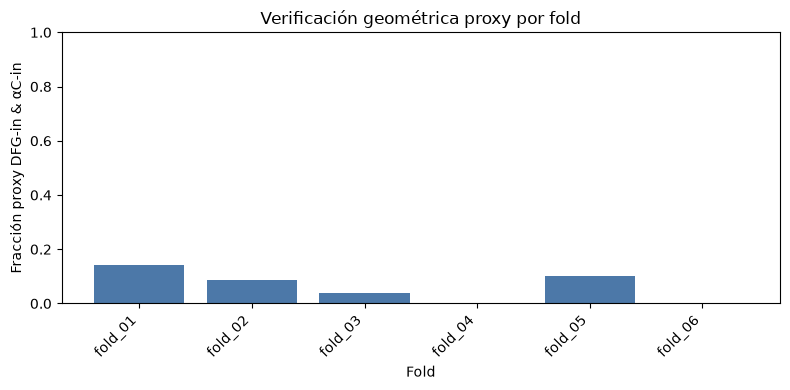

Figura guardada: /Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/figures/physical_plausibility/dfg_alphac_fraction_by_fold.png


In [15]:
if generated_records:
    dfg_rows = [dfg_alphac_metrics(rec) for rec in generated_records]
    dfg_alphac_df = pd.DataFrame(dfg_rows)
else:
    dfg_alphac_df = pd.DataFrame(columns=["fold", "kinase", "sample_id", "mapping_status", "dfg_alphac_in_proxy"])

dfg_csv = RESULTS_DIR / "dfg_alphac_check.csv"
dfg_alphac_df.to_csv(dfg_csv, index=False)
print(f"Guardado: {dfg_csv}")
display(dfg_alphac_df.head())

if not dfg_alphac_df.empty:
    mapped = dfg_alphac_df[dfg_alphac_df["mapping_status"].astype(str).str.startswith("mapped")].copy()
    if not mapped.empty:
        dfg_fold_summary = mapped.groupby("fold", dropna=False).agg(
            n_samples=("sample_id", "count"),
            fraction_dfg_in=("dfg_in_proxy", "mean"),
            fraction_alphac_in=("alphac_in_proxy", "mean"),
            fraction_dfg_alphac_in=("dfg_alphac_in_proxy", "mean"),
        ).reset_index()
    else:
        dfg_fold_summary = pd.DataFrame(columns=["fold", "n_samples", "fraction_dfg_in", "fraction_alphac_in", "fraction_dfg_alphac_in"])
else:
    mapped = pd.DataFrame()
    dfg_fold_summary = pd.DataFrame(columns=["fold", "n_samples", "fraction_dfg_in", "fraction_alphac_in", "fraction_dfg_alphac_in"])

display(dfg_fold_summary)

fig_path = FIGURES_DIR / "dfg_alphac_fraction_by_fold.png"
if not dfg_fold_summary.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(dfg_fold_summary["fold"].astype(str), dfg_fold_summary["fraction_dfg_alphac_in"], color="#4C78A8")
    plt.ylim(0, 1)
    plt.ylabel("Fracción proxy DFG-in & αC-in")
    plt.xlabel("Fold")
    plt.title("Verificación geométrica proxy por fold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print(f"Figura guardada: {fig_path}")
else:
    display(Markdown("No hubo muestras mapeadas para graficar fracción DFG/αC."))


## Designability (ProteinMPNN + ESMFold)

La verificación de designability evalúa si un backbone generado admite una secuencia que luego vuelve a plegarse cerca de esa geometría. El pipeline ideal es:

1. Escribir el backbone generado a PDB.
2. Diseñar secuencia con ProteinMPNN.
3. Re-plegar la secuencia con ESMFold.
4. Calcular RMSD Cα entre ESMFold y el backbone generado.

En este repo las estructuras generadas contienen solo Cα. ProteinMPNN estándar espera backbone completo `N-CA-C-O`, aunque su modo `--ca_only` puede trabajar con modelos CA cuando está disponible. Por eso el notebook intenta usar el modo Cα de ProteinMPNN si encuentra `external/FoldFlow/ProteinMPNN` o un `PROTEINMPNN_DIR` configurado. Si `esm`/ESMFold no está instalado, la sección deja instrucciones y guarda un CSV con estado `skipped`, sin romper la ejecución.


In [16]:
PROTEINMPNN_DIR = Path(os.environ.get("PROTEINMPNN_DIR", ROOT / "external" / "FoldFlow" / "ProteinMPNN"))
OPENFOLD_DIR = Path(os.environ.get("OPENFOLD_DIR", ROOT / "external" / "OpenFold"))


def _patch_openfold_runtime_compat():
    if not hasattr(np, "int"):
        np.int = int
    try:
        import pytorch_lightning.utilities.seed as pl_seed
        if not hasattr(pl_seed, "seed_everything"):
            def seed_everything(seed=None, workers=False):
                import random
                if seed is None:
                    seed = 0
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                return seed
            pl_seed.seed_everything = seed_everything
    except Exception:
        pass
    try:
        import pytorch_lightning.utilities as pl_utils
        if not hasattr(pl_utils, "rank_zero_info"):
            pl_utils.rank_zero_info = lambda *args, **kwargs: None
    except Exception:
        pass

_patch_openfold_runtime_compat()
if OPENFOLD_DIR.exists() and str(OPENFOLD_DIR) not in sys.path:
    sys.path.insert(0, str(OPENFOLD_DIR))
DESIGNABILITY_MAX_SAMPLES = int(os.environ.get("DESIGNABILITY_MAX_SAMPLES", "1000000"))
RUN_DESIGNABILITY_MODE = os.environ.get("RUN_DESIGNABILITY", "auto").strip().lower()
ESMFOLD_NUM_RECYCLES = int(os.environ.get("ESMFOLD_NUM_RECYCLES", "1"))
ESMFOLD_CHUNK_SIZE = int(os.environ.get("ESMFOLD_CHUNK_SIZE", "64"))


def tool_status():
    status = {
        "proteinmpnn_dir": str(PROTEINMPNN_DIR),
        "proteinmpnn_available": (PROTEINMPNN_DIR / "protein_mpnn_run.py").exists(),
        "proteinmpnn_ca_weights": (PROTEINMPNN_DIR / "ca_model_weights" / "v_48_020.pt").exists(),
        "openfold_dir": str(OPENFOLD_DIR),
        "openfold_available": (OPENFOLD_DIR / "openfold").exists(),
    }
    try:
        import esm  # noqa: F401
        status["esm_available"] = True
    except Exception:
        status["esm_available"] = False
    return status

status = tool_status()
RUN_DESIGNABILITY = (
    RUN_DESIGNABILITY_MODE in {"1", "true", "yes", "y"}
    or (RUN_DESIGNABILITY_MODE == "auto" and status["proteinmpnn_available"] and status["proteinmpnn_ca_weights"] and status["esm_available"])
)
status["run_designability"] = RUN_DESIGNABILITY
status["run_designability_mode"] = RUN_DESIGNABILITY_MODE
status["designability_max_samples"] = DESIGNABILITY_MAX_SAMPLES
status["esmfold_num_recycles"] = ESMFOLD_NUM_RECYCLES
status["esmfold_chunk_size"] = ESMFOLD_CHUNK_SIZE
display(pd.DataFrame([status]))

if not RUN_DESIGNABILITY:
    display(Markdown(
        "Designability quedó desactivada porque faltan herramientas o porque `RUN_DESIGNABILITY=0`. "
        "Para forzarla, definir `RUN_DESIGNABILITY=1`."
    ))
else:
    display(Markdown(
        f"Designability está activada en modo `{RUN_DESIGNABILITY_MODE}`. "
        f"Se evaluarán hasta `{DESIGNABILITY_MAX_SAMPLES}` muestras; bajalo con `DESIGNABILITY_MAX_SAMPLES` si querés limitar la corrida."
    ))
if not status["proteinmpnn_available"]:
    display(Markdown("""
ProteinMPNN no está disponible. Instalación sugerida:

```bash
mkdir -p external
git clone https://github.com/dauparas/ProteinMPNN.git external/ProteinMPNN
export PROTEINMPNN_DIR=$PWD/external/ProteinMPNN
```
"""))
if not status["esm_available"]:
    display(Markdown("""
El paquete `esm` de Facebook Research no está disponible en este entorno. Instalación sugerida:

```bash
pip install fair-esm
```

ESMFold puede descargar pesos grandes y puede requerir mucha memoria.
"""))


,proteinmpnn_dir,proteinmpnn_available,proteinmpnn_ca_weights,openfold_dir,openfold_available,esm_available,run_designability,run_designability_mode,designability_max_samples,esmfold_num_recycles,esmfold_chunk_size
0,/Users/josefinadehan/vision_avanzada_t/vision_...,True,True,/Users/josefinadehan/vision_avanzada_t/vision_...,True,True,True,auto,1000000,1,64


Designability está activada en modo `auto`. Se evaluarán hasta `1000000` muestras; bajalo con `DESIGNABILITY_MAX_SAMPLES` si querés limitar la corrida.

### Funciones para backbone Cα, ProteinMPNN y ESMFold

Para alimentar ProteinMPNN en modo Cα se escribe un PDB con átomos `CA` únicamente. Si el modo Cα no está disponible o ESMFold no puede cargarse, cada muestra queda marcada como `skipped` con la causa específica.


In [17]:
def write_ca_only_pdb(coords, path, chain="A"):
    coords = normalize_ca_coords(coords)
    with open(path, "w") as handle:
        for i, (x, y, z) in enumerate(coords, start=1):
            handle.write(
                f"ATOM  {i:5d}  CA  GLY {chain}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        handle.write("TER\nEND\n")
    return path


def read_ca_from_pdb(path):
    coords = []
    with open(path, "r", errors="ignore") as handle:
        for line in handle:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return np.asarray(coords, dtype=np.float32) if coords else None


def kabsch_rmsd_np(mobile, reference):
    mobile = normalize_ca_coords(mobile)
    reference = normalize_ca_coords(reference)
    if mobile is None or reference is None:
        return np.nan
    n = min(len(mobile), len(reference))
    if n < 3:
        return np.nan
    mob = mobile[:n]
    ref = reference[:n]
    mob0 = mob - mob.mean(axis=0)
    ref0 = ref - ref.mean(axis=0)
    cov = mob0.T @ ref0
    v, _, wt = np.linalg.svd(cov)
    d = np.sign(np.linalg.det(v @ wt))
    rot = v @ np.diag([1.0, 1.0, d]) @ wt
    aligned = mob0 @ rot + ref.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((aligned - ref) ** 2, axis=1))))


def parse_first_mpnn_sequence(fasta_path):
    if not Path(fasta_path).exists():
        return None
    seqs = []
    current = []
    for line in Path(fasta_path).read_text().splitlines():
        if line.startswith(">"):
            if current:
                seqs.append(''.join(current))
                current = []
        else:
            current.append(line.strip())
    if current:
        seqs.append(''.join(current))
    # ProteinMPNN suele escribir primero la secuencia original; tomar la primera diseñada si existe.
    return seqs[1] if len(seqs) > 1 else (seqs[0] if seqs else None)


def run_proteinmpnn_ca(pdb_path, out_dir):
    if not (PROTEINMPNN_DIR / "protein_mpnn_run.py").exists():
        return None, "ProteinMPNN no disponible"
    cmd = [
        sys.executable,
        str(PROTEINMPNN_DIR / "protein_mpnn_run.py"),
        "--pdb_path", str(pdb_path),
        "--out_folder", str(out_dir),
        "--num_seq_per_target", "1",
        "--sampling_temp", "0.1",
        "--seed", "123",
        "--batch_size", "1",
        "--ca_only",
        "--path_to_model_weights", str(PROTEINMPNN_DIR / "ca_model_weights"),
    ]
    proc = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    if proc.returncode != 0:
        return None, proc.stdout[-2000:]
    fasta_files = sorted((Path(out_dir) / "seqs").glob("*.fa"))
    if not fasta_files:
        return None, "ProteinMPNN no produjo FASTA"
    seq = parse_first_mpnn_sequence(fasta_files[0])
    return seq, None if seq else "No se pudo leer secuencia diseñada"


_ESMFOLD_MODEL = None


def get_esmfold_model():
    global _ESMFOLD_MODEL
    _patch_openfold_runtime_compat()
    if OPENFOLD_DIR.exists() and str(OPENFOLD_DIR) not in sys.path:
        sys.path.insert(0, str(OPENFOLD_DIR))
    if _ESMFOLD_MODEL is not None:
        return _ESMFOLD_MODEL, None
    try:
        import esm
        model = esm.pretrained.esmfold_v1()
        model = model.eval()
        if hasattr(model, "set_chunk_size"):
            model.set_chunk_size(ESMFOLD_CHUNK_SIZE)
        if torch.cuda.is_available():
            model = model.cuda()
        _ESMFOLD_MODEL = model
        return _ESMFOLD_MODEL, None
    except Exception as exc:
        return None, f"ESMFold no disponible/cargable: {type(exc).__name__}: {exc}"


def run_esmfold(seq):
    model, err = get_esmfold_model()
    if err:
        return None, err
    try:
        with torch.no_grad():
            pdb = model.infer_pdb(seq, num_recycles=ESMFOLD_NUM_RECYCLES)
        return pdb, None
    except Exception as exc:
        return None, f"ESMFold falló: {type(exc).__name__}: {exc}"


def designability_for_record(rec, work_root):
    sample_id = str(rec.get("sample_id", "sample")).replace("/", "_")
    sample_dir = Path(work_root) / sample_id
    sample_dir.mkdir(parents=True, exist_ok=True)

    generated = normalize_ca_coords(rec.get("generated_coords"))
    if generated is None or len(generated) < 10:
        return {
            "fold": rec.get("fold"),
            "kinase": rec.get("kinase"),
            "sample_id": rec.get("sample_id"),
            "source": rec.get("source"),
            "status": "skipped",
            "reason": "generated backbone missing or too short",
            "designability_rmsd": np.nan,
        }

    generated_pdb = sample_dir / "generated_ca_only.pdb"
    write_ca_only_pdb(generated, generated_pdb)

    mpnn_dir = sample_dir / "proteinmpnn"
    seq, mpnn_err = run_proteinmpnn_ca(generated_pdb, mpnn_dir)
    if mpnn_err:
        return {
            "fold": rec.get("fold"),
            "kinase": rec.get("kinase"),
            "sample_id": rec.get("sample_id"),
            "source": rec.get("source"),
            "status": "proteinmpnn_error",
            "reason": mpnn_err,
            "designed_sequence": seq,
            "sequence_length": len(seq) if seq else np.nan,
            "designability_rmsd": np.nan,
        }

    esm_pdb, esm_err = run_esmfold(seq)
    if esm_err:
        return {
            "fold": rec.get("fold"),
            "kinase": rec.get("kinase"),
            "sample_id": rec.get("sample_id"),
            "source": rec.get("source"),
            "status": "esmfold_error",
            "reason": esm_err,
            "designed_sequence": seq,
            "sequence_length": len(seq),
            "designability_rmsd": np.nan,
        }

    esm_pdb_path = sample_dir / "esmfold_prediction.pdb"
    esm_pdb_path.write_text(esm_pdb)
    esm_ca = read_ca_from_pdb(esm_pdb_path)
    rmsd = kabsch_rmsd_np(esm_ca, generated)
    return {
        "fold": rec.get("fold"),
        "kinase": rec.get("kinase"),
        "sample_id": rec.get("sample_id"),
        "source": rec.get("source"),
        "status": "ok" if np.isfinite(rmsd) else "rmsd_error",
        "reason": None if np.isfinite(rmsd) else "could not compute Cα RMSD",
        "designed_sequence": seq,
        "sequence_length": len(seq),
        "designability_rmsd": rmsd,
        "generated_pdb": str(generated_pdb),
        "esmfold_pdb": str(esm_pdb_path),
    }


### Ejecutar designability y guardar resultados

La ejecución queda en modo `auto`: corre si ProteinMPNN CA-only y ESMFold están disponibles, y se limita con `DESIGNABILITY_MAX_SAMPLES` para evitar corridas accidentales muy largas. Si faltan herramientas, el CSV registra `skipped` en vez de simular resultados.


In [18]:
def designability_preflight():
    result = {
        "deepspeed_path": None,
        "deepspeed_has_utils": False,
        "deepspeed_utils_initialized": False,
        "esmfold_infer_ok": False,
        "esmfold_pdb_len": np.nan,
        "error": None,
    }
    try:
        import deepspeed
        result["deepspeed_path"] = getattr(deepspeed, "__file__", None)
        result["deepspeed_has_utils"] = hasattr(deepspeed, "utils")
        if result["deepspeed_has_utils"]:
            result["deepspeed_utils_initialized"] = bool(deepspeed.utils.is_initialized())
        else:
            raise AttributeError("deepspeed.utils missing")
        pdb, err = run_esmfold("ACDEFGHIKLMNPQRSTVWY")
        if err:
            raise RuntimeError(err)
        result["esmfold_infer_ok"] = True
        result["esmfold_pdb_len"] = len(pdb)
    except Exception as exc:
        result["error"] = f"{type(exc).__name__}: {exc}"
    return result


preflight = designability_preflight()
display(pd.DataFrame([preflight]))
if preflight["esmfold_infer_ok"]:
    display(Markdown("Preflight OK: `deepspeed.utils` está disponible y ESMFold respondió a una inferencia corta."))
else:
    display(Markdown(f"Preflight falló: `{preflight['error']}`"))

designability_rows = []
if not generated_records:
    designability_rows.append({"status": "skipped", "reason": "no generated records available", "designability_rmsd": np.nan})
elif not RUN_DESIGNABILITY:
    for rec in generated_records:
        designability_rows.append({
            "fold": rec.get("fold"),
            "kinase": rec.get("kinase"),
            "sample_id": rec.get("sample_id"),
            "source": rec.get("source"),
            "status": "skipped_disabled",
            "reason": "RUN_DESIGNABILITY is false",
            "designability_rmsd": np.nan,
        })
else:
    work_root = RESULTS_DIR / "designability_work"
    work_root.mkdir(parents=True, exist_ok=True)
    for rec in generated_records[:DESIGNABILITY_MAX_SAMPLES]:
        try:
            designability_rows.append(designability_for_record(rec, work_root))
        except Exception as exc:
            designability_rows.append({
                "fold": rec.get("fold"),
                "kinase": rec.get("kinase"),
                "sample_id": rec.get("sample_id"),
                "source": rec.get("source"),
                "status": "error",
                "reason": f"{type(exc).__name__}: {exc}",
                "designability_rmsd": np.nan,
            })

designability_df = pd.DataFrame(designability_rows)
design_csv = RESULTS_DIR / "designability_check.csv"
designability_df.to_csv(design_csv, index=False)
print(f"Guardado: {design_csv}")
display(designability_df.head())

ok_design = designability_df[designability_df.get("status", pd.Series(dtype=str)).eq("ok")].copy() if not designability_df.empty else pd.DataFrame()
if not ok_design.empty:
    design_fold_summary = ok_design.groupby("fold", dropna=False).agg(
        n_designable=("sample_id", "count"),
        median_designability_rmsd=("designability_rmsd", "median"),
        mean_designability_rmsd=("designability_rmsd", "mean"),
    ).reset_index()
else:
    design_fold_summary = pd.DataFrame(columns=["fold", "n_designable", "median_designability_rmsd", "mean_designability_rmsd"])

display(design_fold_summary)

fig_path = FIGURES_DIR / "designability_rmsd_distribution.png"
if not ok_design.empty:
    plt.figure(figsize=(7, 4))
    plt.hist(ok_design["designability_rmsd"].dropna(), bins=20, color="#F58518", alpha=0.85)
    plt.xlabel("RMSD Cα ESMFold vs backbone generado (Å)")
    plt.ylabel("Cantidad")
    plt.title("Distribución de RMSD de designability")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print(f"Figura guardada: {fig_path}")
else:
    display(Markdown("No hay resultados `ok` de designability para graficar RMSD."))


/Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/external/OpenFold/openfold/utils/tensor_utils.py:92: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


,deepspeed_path,deepspeed_has_utils,deepspeed_utils_initialized,esmfold_infer_ok,esmfold_pdb_len,error
0,/Users/josefinadehan/vision_avanzada_t/vision_...,True,False,True,13569,None


Preflight OK: `deepspeed.utils` está disponible y ESMFold respondió a una inferencia corta.

/Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/external/OpenFold/openfold/utils/tensor_utils.py:92: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


KeyboardInterrupt: 

## Síntesis por fold

La tabla siguiente combina la fracción proxy `DFG-in & αC-in` con el RMSD de designability cuando existe. Las dos verificaciones responden preguntas distintas: DFG/αC evalúa si la geometría se acerca a una conformación activa esperada de quinasa; designability evalúa si la geometría parece compatible con una proteína plegable. Pasar una sin pasar la otra no tiene la misma interpretación biológica.


In [ ]:
summary = dfg_fold_summary.copy() if "dfg_fold_summary" in globals() else pd.DataFrame()
if summary.empty:
    summary = pd.DataFrame(columns=["fold", "n_samples", "fraction_dfg_alphac_in"])
if "design_fold_summary" in globals() and not design_fold_summary.empty:
    summary = summary.merge(design_fold_summary, on="fold", how="outer")
else:
    summary["n_designable"] = 0
    summary["median_designability_rmsd"] = np.nan
    summary["mean_designability_rmsd"] = np.nan

summary_csv = RESULTS_DIR / "physical_plausibility_summary_by_fold.csv"
summary.to_csv(summary_csv, index=False)
print(f"Guardado: {summary_csv}")
display(summary)


Guardado: /Users/josefinadehan/vision_avanzada_t/vision_avanzada_t/results/physical_plausibility/physical_plausibility_summary_by_fold.csv


,fold,n_samples,fraction_dfg_in,fraction_alphac_in,fraction_dfg_alphac_in,n_designable,median_designability_rmsd,mean_designability_rmsd
0,fold_01,7,0.428571,0.142857,0.142857,0,NaN,NaN
1,fold_02,23,0.304348,0.391304,0.086957,0,NaN,NaN
2,fold_03,160,0.31875,0.04375,0.0375,0,NaN,NaN
3,fold_04,26,0.115385,0.115385,0.0,0,NaN,NaN
4,fold_05,10,0.3,0.5,0.1,0,NaN,NaN
5,fold_06,2,0.5,0.5,0.0,0,NaN,NaN


## Limitaciones

- La verificación DFG/αC mide sobre coordenadas Cα generadas. Aunque el pipeline actualizado puede usar `pocket` y `klifs_to_ca_index` para ubicar el motivo DFG con mayor precisión, no evalúa átomos de cadena lateral, rotámeros ni distancias catalíticas completas.
- Si los artefactos disponibles fueron generados antes de propagar `pocket`, `klifs_residue_map` y `klifs_to_ca_index`, el notebook usa una aproximación basada en el PDB inactivo y reporta el nivel de mapeo en `mapping_status`. Las muestras sin mapeo quedan como `unmapped`.
- La región αC se trata como una ventana geométrica/proxy salvo que el dataset incluya una definición explícita de las posiciones KLIFS usadas para αC-in. Por eso la etiqueta DFG/αC debe interpretarse como criterio geométrico operativo, no como anotación estructural completa.
- Designability evalúa consistencia física aproximada de una geometría con una secuencia diseñada y re-plegada. No demuestra actividad biológica real ni que esa conformación exista necesariamente en la naturaleza.
- Si `ProteinMPNN` o `esm`/ESMFold no están disponibles, el notebook guarda la verificación como `skipped` en el CSV en vez de simular resultados.
- Si no existen checkpoints en `checkpoints/egnn_loko`, el notebook no re-entrena la EGNN. Puede usar coordenadas ya generadas por `04` como fallback de solo lectura, y lo marca explícitamente en la columna `source`.
